### Flux text encoder test
1) loads pretrained flux text encoder
2) shows how to process a prompt
3) passes it to flux klein model to check this is correct

In [14]:
from transformers import Qwen2TokenizerFast, Qwen3ForCausalLM, AutoConfig
import torch
import time

device = "cuda"

In [2]:
text_encoder = Qwen3ForCausalLM.from_pretrained("../FLUX.2-klein-4B/text_encoder", local_files_only=True).to(device)
tokenizer = Qwen2TokenizerFast.from_pretrained("../FLUX.2-klein-4B/tokenizer", local_files_only=True, device=device)

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

In [3]:
def _get_qwen3_prompt_embeds(
    text_encoder: Qwen3ForCausalLM,
    tokenizer: Qwen2TokenizerFast,
    prompt: str | list[str],
    dtype: torch.dtype | None = None,
    device: torch.device | None = None,
    max_sequence_length: int = 512,
    hidden_states_layers: list[int] = (9, 18, 27),
):
    dtype = text_encoder.dtype if dtype is None else dtype
    device = text_encoder.device if device is None else device

    prompt = [prompt] if isinstance(prompt, str) else prompt

    all_input_ids = []
    all_attention_masks = []

    for single_prompt in prompt:
        messages = [{"role": "user", "content": single_prompt}]
        text = tokenizer.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True,
            enable_thinking=False,
        )
        inputs = tokenizer(
            text,
            return_tensors="pt",
            padding="max_length",
            truncation=True,
            max_length=max_sequence_length,
        )

        all_input_ids.append(inputs["input_ids"])
        all_attention_masks.append(inputs["attention_mask"])

    input_ids = torch.cat(all_input_ids, dim=0).to(device)
    attention_mask = torch.cat(all_attention_masks, dim=0).to(device)

    # Forward pass through the model
    output = text_encoder(
        input_ids=input_ids,
        attention_mask=attention_mask,
        output_hidden_states=True,
        use_cache=False,
    )

    # Only use outputs from intermediate layers and stack them
    out = torch.stack(
        [output.hidden_states[k] for k in hidden_states_layers], dim=1
    )
    out = out.to(dtype=dtype, device=device)

    batch_size, num_channels, seq_len, hidden_dim = out.shape
    prompt_embeds = out.permute(0, 2, 1, 3).reshape(
        batch_size, seq_len, num_channels * hidden_dim
    )

    return prompt_embeds

def _prepare_text_ids(
    x: torch.Tensor,  # (B, L, D) or (L, D)
    t_coord: torch.Tensor | None = None,
):
    B, L, _ = x.shape
    out_ids = []

    for i in range(B):
        t = torch.arange(1) if t_coord is None else t_coord[i]
        h = torch.arange(1)
        w = torch.arange(1)
        l = torch.arange(L)

        coords = torch.cartesian_prod(t, h, w, l)
        out_ids.append(coords)

    return torch.stack(out_ids)


def encode_prompt(
    prompt: str | list[str],
    device: torch.device | None = None,
    num_images_per_prompt: int = 1,
    prompt_embeds: torch.Tensor | None = None,
    max_sequence_length: int = 512,
    text_encoder_out_layers: tuple[int] = (9, 18, 27),
):
    prompt = [prompt] if isinstance(prompt, str) else prompt

    prompt_embeds = _get_qwen3_prompt_embeds(
        text_encoder=text_encoder,
        tokenizer=tokenizer,
        prompt=prompt,
        device=device,
        max_sequence_length=max_sequence_length,
        hidden_states_layers=text_encoder_out_layers,
    )

    batch_size, seq_len, _ = prompt_embeds.shape
    prompt_embeds = prompt_embeds.repeat(1, num_images_per_prompt, 1)
    prompt_embeds = prompt_embeds.view(
        batch_size * num_images_per_prompt, seq_len, -1
    )

    text_ids = _prepare_text_ids(prompt_embeds)
    text_ids = text_ids.to(device)
    return prompt_embeds, text_ids

In [9]:
prompt = "A cat is on the green grass"

prompt_embeds, text_ids = encode_prompt(
    prompt=prompt,
    device=device,
    num_images_per_prompt=1,
    max_sequence_length=512,
    text_encoder_out_layers=(9, 18, 27),
)

In [10]:
prompt_embeds.shape

torch.Size([1, 512, 7680])

In [11]:
# check that the embeds are computed correct

import torch
from diffusers import Flux2KleinPipeline
from diffusers.schedulers import FlowMatchEulerDiscreteScheduler
from diffusers.models import AutoencoderKLFlux2, Flux2Transformer2DModel

import matplotlib.pyplot as plt
from diffusers.utils import load_image

dtype = torch.bfloat16

scheduler = FlowMatchEulerDiscreteScheduler.from_pretrained("../FLUX.2-klein-4B/scheduler", device=device)
vae = AutoencoderKLFlux2.from_pretrained("../FLUX.2-klein-4B/vae", device=device).to(dtype)
transformer = Flux2Transformer2DModel.from_pretrained("../FLUX.2-klein-4B/transformer", device=device).to(dtype)
pipe = Flux2KleinPipeline(scheduler=scheduler, vae=vae, text_encoder=text_encoder, tokenizer=tokenizer, transformer=transformer)
pipe = pipe.to(device)

  0%|          | 0/4 [00:00<?, ?it/s]

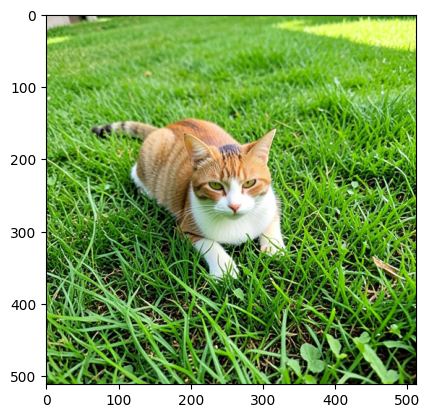

In [12]:
image = pipe(
    prompt_embeds=prompt_embeds,
    height=512,
    width=512,
    guidance_scale=1.0,
    num_inference_steps=4,
    generator=torch.Generator(device=device).manual_seed(0)
).images[0]

plt.imshow(image)
plt.show()

In [15]:
for i in range(10):
    t = time.time()
    prompt_embeds, text_ids = encode_prompt(
        prompt=prompt,
        device=device,
        num_images_per_prompt=1,
        max_sequence_length=512,
        text_encoder_out_layers=(9, 18, 27),
    )
    print("encode time", time.time() - t)

encode time 0.045175790786743164
encode time 0.0354313850402832
encode time 0.03470969200134277
encode time 0.03442740440368652
encode time 0.0343937873840332
encode time 0.03472733497619629
encode time 0.0349116325378418
encode time 0.034864187240600586
encode time 0.03467059135437012
encode time 0.03447413444519043


In [16]:
118287 * 512 * 7680 * 2 // 1024 // 1024 // 1024

866

So, 866 GB is too much for storage.